# Paso 6: Modelamiento (XGBoost, LightGBM y Stacking)

Este notebook implementa el **Paso 6** del pipeline para la tesis:
**"Detección de ataques minoritarios en redes IoT mediante un modelo híbrido basado en Stacking, XGBoost y LightGBM, Puno 2026"**.

### Objetivos del Notebook:
1. **Entrenar el Modelo Base 1 (XGBoost)** acelerado por GPU (usando CUDA en la RTX 5070 Ti).
2. **Entrenar el Modelo Base 2 (LightGBM)** optimizado por CPU multihilo.
3. **Entrenar el Modelo Ensemble (Stacking Classifier)** combinando ambos modelos base con un meta-clasificador (`LogisticRegression`).
4. **Evaluar y comparar** el rendimiento de los tres modelos en el conjunto de prueba aislado (503,177 registros) a través de informes de clasificación detallados (precisión, recall, F1-score).
5. **Generar matrices de confusión** y guardarlas en `results/figures/`.
6. **Evaluar la importancia de características** de los modelos base para aportar explicabilidad.

In [1]:
import os
import pandas as pd
import numpy as np
import json
import joblib
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
import xgboost as xgb
import lightgbm as lgb

# Cambiar el directorio de trabajo a la raíz del proyecto si el notebook se ejecuta desde 'notebooks'
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
print(f"Directorio de trabajo activo: {os.getcwd()}")

# Estilo gráfico premium
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
os.makedirs("results/figures", exist_ok=True)
os.makedirs("models", exist_ok=True)

Directorio de trabajo activo: /home/carmen/tesis_iot


In [2]:
# Cargar datos de entrenamiento balanceados con SMOTE y prueba
print("Cargando conjunto de entrenamiento balanceado con SMOTE...")
X_train = pd.read_csv("data/processed/X_train_resampled.csv")
y_train = pd.read_csv("data/processed/y_train_resampled.csv").values.ravel()

print("Cargando conjunto de prueba aislado...")
X_test = pd.read_csv("data/processed/X_test.csv")
y_test = pd.read_csv("data/processed/y_test.csv").values.ravel()

# Cargar mapeo de etiquetas
with open("results/label_mapping.json", "r") as f:
    label_mapping = json.load(f)
class_names = list(label_mapping.keys())

print(f"¡Datos cargados! Entrenamiento: {X_train.shape[0]:,}, Prueba: {X_test.shape[0]:,}")

Cargando conjunto de entrenamiento balanceado con SMOTE...
Cargando conjunto de prueba aislado...
¡Datos cargados! Entrenamiento: 2,183,723, Prueba: 503,177


## 1. Entrenamiento de XGBoost (Acelerado por GPU)

In [3]:
print("Configurando XGBoost con soporte para GPU...")
# Configuramos device='cuda' para usar GPU y tree_method='hist' que es muy veloz
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    tree_method='hist',
    device='cuda',
    random_state=42,
    n_jobs=-1
)

start_time = time.time()
print("Entrenando XGBoost en GPU...")
xgb_model.fit(X_train, y_train)
xgb_train_time = time.time() - start_time
print(f"¡XGBoost entrenado en {xgb_train_time:.2f} segundos!")

# Guardar el modelo
xgb_model.save_model("models/xgboost_model.json")

Configurando XGBoost con soporte para GPU...
Entrenando XGBoost en GPU...
¡XGBoost entrenado en 10.62 segundos!


## 2. Entrenamiento de LightGBM (CPU Multihilo)

In [4]:
print("Configurando LightGBM...")
lgb_model = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    num_leaves=31,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

start_time = time.time()
print("Entrenando LightGBM...")
lgb_model.fit(X_train, y_train)
lgb_train_time = time.time() - start_time
print(f"¡LightGBM entrenado en {lgb_train_time:.2f} segundos!")

# Guardar el modelo
lgb_model.booster_.save_model("models/lightgbm_model.txt")

Configurando LightGBM...
Entrenando LightGBM...
¡LightGBM entrenado en 34.98 segundos!


## 3. Entrenamiento del Modelo Híbrido (Stacking)

In [5]:
print("Configurando Stacking Classifier...")
# Definimos los modelos base utilizando los hiperparámetros anteriores
estimators = [
    ('xgb', xgb.XGBClassifier(
        n_estimators=100, learning_rate=0.1, max_depth=6, 
        tree_method='hist', device='cuda', random_state=42, n_jobs=-1
    )),
    ('lgb', lgb.LGBMClassifier(
        n_estimators=100, learning_rate=0.1, max_depth=6, 
        num_leaves=31, random_state=42, n_jobs=-1, verbosity=-1
    ))
]

# Usamos Regresión Logística como Meta-Clasificador y CV=3 para acelerar el proceso
stacking_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=3,
    n_jobs=1, # Se ejecuta secuencialmente para que XGBoost no compita por memoria GPU en hilos paralelos
    passthrough=False
)

start_time = time.time()
print("Entrenando Stacking Classifier (esto puede tardar unos 2-3 minutos)...")
stacking_model.fit(X_train, y_train)
stacking_train_time = time.time() - start_time
print(f"¡Stacking Classifier entrenado en {stacking_train_time:.2f} segundos!")

# Guardar el modelo en disco
joblib.dump(stacking_model, "models/stacking_model.joblib")
print("Modelo Stacking guardado en 'models/stacking_model.joblib'")

Configurando Stacking Classifier...
Entrenando Stacking Classifier (esto puede tardar unos 2-3 minutos)...


/home/carmen/miniconda3/envs/tesis_iot/lib/python3.10/site-packages/xgboost/core.py:751: UserWarning: [23:12:25] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


¡Stacking Classifier entrenado en 188.81 segundos!
Modelo Stacking guardado en 'models/stacking_model.joblib'


## 4. Evaluación en el Conjunto de Prueba y Reportes de Métricas

In [6]:
def evaluar_modelo(model, name, X_test, y_test, class_names):
    print(f"\n=== Evaluando modelo: {name} ===")
    preds = model.predict(X_test)
    
    # Generar informe de clasificación
    report = classification_report(y_test, preds, target_names=class_names, output_dict=True)
    df_report = pd.DataFrame(report).transpose()
    
    # Guardar reporte
    df_report.to_csv(f"results/reporte_{name.lower()}.csv")
    print(f"Reporte guardado en 'results/reporte_{name.lower()}.csv'")
    
    # Imprimir resumen de métricas clave
    accuracy = accuracy_score(y_test, preds)
    print(f"Exactitud Global (Accuracy): {accuracy*100:.4f}%")
    
    # Mostrar el reporte formateado en pantalla
    print(classification_report(y_test, preds, target_names=class_names))
    
    # Generar y guardar la matriz de confusión gráfica
    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Matriz de Confusión - {name}", fontsize=14, fontweight='bold', pad=15)
    plt.ylabel("Clase Real")
    plt.xlabel("Clase Predicha")
    plt.tight_layout()
    plt.savefig(f"results/figures/matriz_confusion_{name.lower()}.png", dpi=300)
    plt.close()
    print(f"Matriz de confusión guardada en 'results/figures/matriz_confusion_{name.lower()}.png'")
    
    return df_report

# Evaluar los tres modelos
report_xgb = evaluar_modelo(xgb_model, "XGBoost", X_test, y_test, class_names)
report_lgb = evaluar_modelo(lgb_model, "LightGBM", X_test, y_test, class_names)
report_stack = evaluar_modelo(stacking_model, "Stacking", X_test, y_test, class_names)


=== Evaluando modelo: XGBoost ===
Reporte guardado en 'results/reporte_xgboost.csv'
Exactitud Global (Accuracy): 84.3516%
              precision    recall  f1-score   support

      Benign       0.65      0.57      0.61     25055
 Brute Force       0.57      0.34      0.42      2504
        DDoS       0.89      0.91      0.90    197967
         DoS       0.73      0.67      0.70     69260
       Mirai       1.00      1.00      1.00     73914
       Recon       0.75      0.89      0.81     82996
    Spoofing       0.89      0.72      0.79     46740
   Web-based       0.58      0.17      0.26      4741

    accuracy                           0.84    503177
   macro avg       0.76      0.66      0.69    503177
weighted avg       0.84      0.84      0.84    503177

Matriz de confusión guardada en 'results/figures/matriz_confusion_xgboost.png'

=== Evaluando modelo: LightGBM ===
Reporte guardado en 'results/reporte_lightgbm.csv'
Exactitud Global (Accuracy): 83.5130%
              precisio

## 5. Comparativa de F1-Score para las Clases Minoritarias

El principal objetivo de la tesis es mejorar el rendimiento de detección en ataques minoritarios (`Web-based` y `Brute Force`). Analicemos cómo se compara el F1-Score entre los tres modelos para cada clase.

Comparativa de F1-Score por Clase:
         Clase  XGBoost  LightGBM  Stacking
0       Benign   0.6086    0.6244    0.6196
1  Brute Force   0.4248    0.4301    0.4335
2         DDoS   0.8995    0.8896    0.8942
3          DoS   0.6972    0.6857    0.6863
4        Mirai   0.9977    0.9599    0.9815
5        Recon   0.8142    0.8192    0.8203
6     Spoofing   0.7933    0.8026    0.8039
7    Web-based   0.2620    0.2856    0.3116


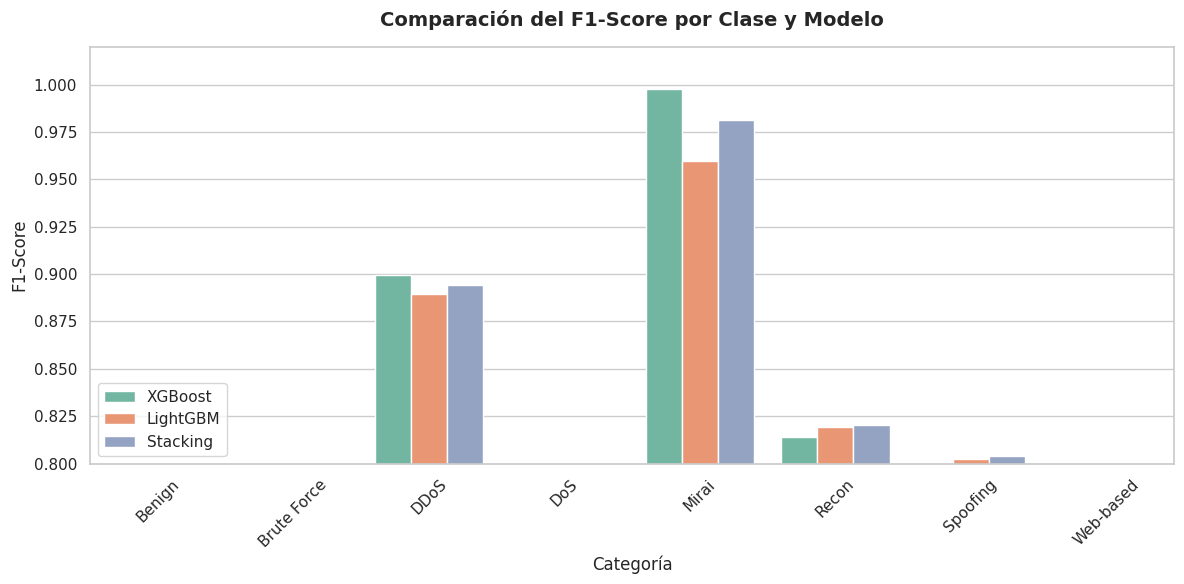

In [7]:
# Extraer F1-scores para cada clase
classes_eval = class_names

f1_comparison = pd.DataFrame({
    'Clase': classes_eval,
    'XGBoost': [report_xgb.loc[c, 'f1-score'] for c in classes_eval],
    'LightGBM': [report_lgb.loc[c, 'f1-score'] for c in classes_eval],
    'Stacking': [report_stack.loc[c, 'f1-score'] for c in classes_eval]
})

print("Comparativa de F1-Score por Clase:")
print(f1_comparison.round(4))

# Guardar comparativa
f1_comparison.to_csv("results/comparativa_f1_score.csv", index=False)

# Gráfico comparativo
df_melted = pd.melt(f1_comparison, id_vars=['Clase'], var_name='Modelo', value_name='F1-Score')
plt.figure(figsize=(12, 6))
sns.barplot(data=df_melted, x='Clase', y='F1-Score', hue='Modelo', palette='Set2')
plt.title("Comparación del F1-Score por Clase y Modelo", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Categoría")
plt.ylabel("F1-Score")
plt.ylim(0.8, 1.02) # Acercamos la vista para apreciar mejor las diferencias
plt.xticks(rotation=45)
plt.legend(loc='lower left')
plt.tight_layout()
plt.savefig("results/figures/11_comparativa_f1_score.png", dpi=300)
plt.show()

## 6. Importancia de Características (Explicabilidad)

Analicemos cuáles fueron las 10 características más determinantes para las decisiones de XGBoost y LightGBM.


Top 10 Características más Importantes (Normalizadas):
   Característica  XGBoost  LightGBM   Media
1   Protocol Type   0.3508    0.0100  0.1804
34         Number   0.1979    0.0482  0.1231
30            Max   0.0135    0.1070  0.0602
32       Tot size   0.0343    0.0789  0.0566
33            IAT   0.0134    0.0739  0.0437
23            UDP   0.0558    0.0314  0.0436
0   Header_Length   0.0232    0.0600  0.0416
2    Time_To_Live   0.0042    0.0784  0.0413
16          HTTPS   0.0153    0.0600  0.0376
20            SSH   0.0339    0.0221  0.0280


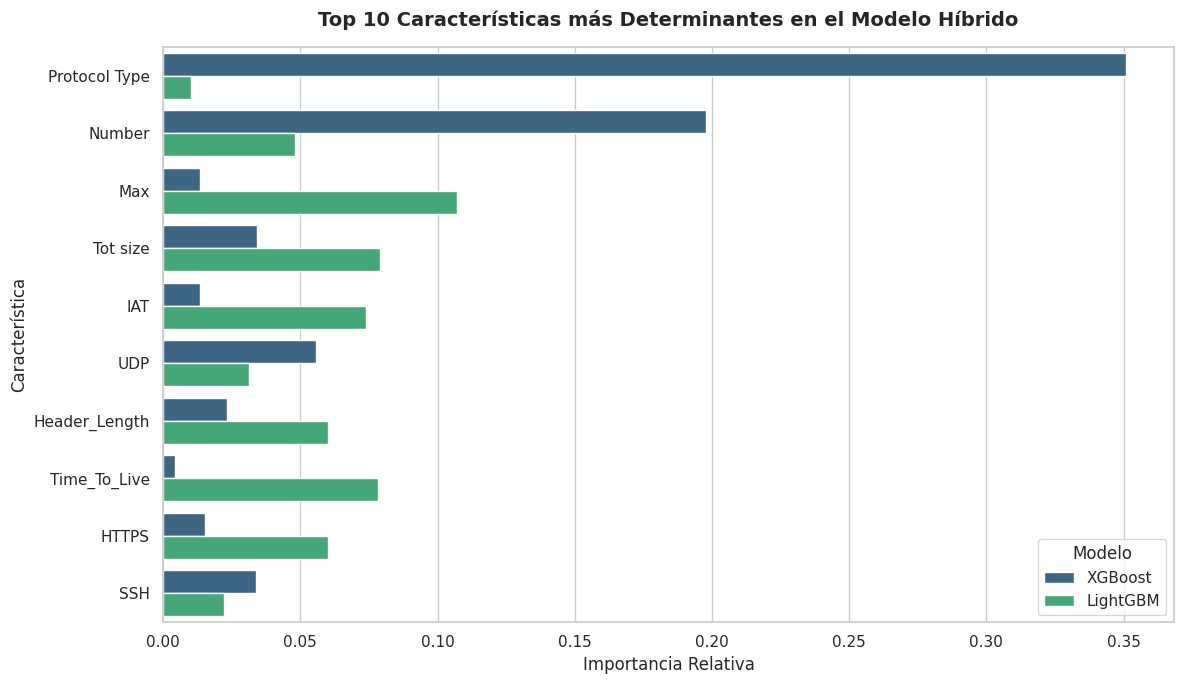

In [8]:
# Obtener importancia de características
features = X_train.columns

xgb_importances = xgb_model.feature_importances_
lgb_importances = lgb_model.feature_importances_ / lgb_model.feature_importances_.sum()

df_importance = pd.DataFrame({
    'Característica': features,
    'XGBoost': xgb_importances,
    'LightGBM': lgb_importances
})

# Seleccionar las top 10 basadas en la media de importancia
df_importance['Media'] = df_importance[['XGBoost', 'LightGBM']].mean(axis=1)
df_importance = df_importance.sort_values(by='Media', ascending=False).head(10)

print("\nTop 10 Características más Importantes (Normalizadas):")
print(df_importance.round(4))

# Guardar tabla de importancia
df_importance.to_csv("results/importancia_caracteristicas.csv", index=False)

# Graficar comparativa de importancia
df_imp_melted = pd.melt(df_importance.drop(columns=['Media']), id_vars=['Característica'], var_name='Modelo', value_name='Importancia')
plt.figure(figsize=(12, 7))
sns.barplot(data=df_imp_melted, x='Importancia', y='Característica', hue='Modelo', palette='viridis')
plt.title("Top 10 Características más Determinantes en el Modelo Híbrido", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Importancia Relativa")
plt.ylabel("Característica")
plt.tight_layout()
plt.savefig("results/figures/12_importancia_caracteristicas.png", dpi=300)
plt.show()